# Proper Orthogonal Decomposition

This section demonstrates the implementation of proper orthogonal decomposition (POD) for dimensionality reduction and high-dimensional modeling. Make sure that you have downloaded and installed the latest release of the `scimlstudio` package before running the code in this section. The implementation given in this section is based on the following sources in the literature:

[1] [K. Decker, N. Iyengar, D. Rajaram, C. Perron, and D. Mavris, “Manifold Alignment-Based nonintrusive and nonlinear multifidelity Reduced-Order modeling,” AIAA Journal, vol. 61, no. 1, pp. 454–474, Oct. 2022](https://arc.aiaa.org/doi/10.2514/1.J061720)

[2] [K. Decker, H. D. Schwartz, and D. Mavris, “Dimensionality reduction techniques applied to the design of hypersonic aerial systems,” in AIAA AVIATION 2020 FORUM, Virtual Conference, Jun. 2020](https://arc.aiaa.org/doi/10.2514/6.2020-3003)

[3] [H. Nobach, C. Tropea, C. Laurent, J. Bonnet, J. Delville, J. Lewalle, M. Farge, K. Schneider and R. Adrian, “Review of Some Fundamentals of Data Processing,” in Springer Handbook of Experimental Fluid Mechanics, 2007, pp. 1337–1398](https://link.springer.com/rwe/10.1007/978-3-540-30299-5_22)

## Theory

POD is a linear dimensionality reduction method that projects high-dimensional data, $x\in \mathbb{R}^n$, to a low-dimensional representation, $z\in \mathbb{R}^k$, where $k << n$. The fact that POD is a linear dimensionality reduction method means that it is only able to capture the linear trends and features of the data but cannot capture nonlinear features in the data such as discontinuities. In engineering settings, POD can be useful in creating a low-dimensional projection of high-dimensional data to better facilitate the process of surrogate modeling.

The main steps in the process of POD are given below. For this explaination, consider that $X \in \mathbb{R}^{n\times m}$, is a matrix where each column of the matrix represents the high-dimensional data of the system. For example, this could be the pressure field output from a fluids simulation or the stress field output from a structures simulation. $X$ is also called the snapshot matrix in some sources within the literature. It is assumed that any data preprocessing steps such as standardization transforms or centering have already been performed on the data. There are a total of $p$ instances of the high-dimensional data, typically drawn from sampling points generated from a design of experiments. 

1. **Perform singular value decomposition (SVD) on the high-dimensional data:** SVD is used to decompose the matrix $X$ into three separate matrices, $X = U\Sigma V^T$, where columns of $U \in \mathbb{R}^{n \times n}$ contain the eigenvectors of $XX^T$, columns of $V \in \mathbb{R}^{m \times m}$ contain the eignevectors of $X^TX$, and $\Sigma \in \mathbb{R}^{n\times m}$ is a diagonal matrix containing the singular values of the matrix. The singular values, $\sigma_i$, are arranged in descending order such that $\sigma_1 \leq \sigma_2 \leq \dots \leq \sigma_r$ along the diagonal and $r=\min(n,m)$. The columns of $U$ form the POD modes of the matrix $X$. 

2. **Truncate the columns of $U$ to obtain the POD modes:** After obtaining the SVD of the matrix, the columns of $U$ must be truncated since the full matrix $X$ can be represented effectively using only a few POD modes. The truncation involves calculating the relative information criterion (RIC) and using the number of modes that can meet the threshold of RIC that is set by the user. A threshold of 0.9999 is a common choice for RIC. The RIC is a function of $k$, which is the number of POD modes that are retained in the truncation. The RIC can be written as follows:

$$\text{RIC}(k) = \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{j=1}^n \sigma_j^2}$$

Once the value of $k$ is found using RIC, the first $k$ columns of $U$ are the representative POD modes for the data. The matrix with the first $k$ columns of $U$ is denoted as $U_k \in \mathbb{R}^{n\times k}$. Similarly, truncated forms of $\Sigma$ and $V$ can also be formed and denoted as $\Sigma_k \in \mathbb{R}^{k\times k}$ and $V_k \in \mathbb{R}^{m \times k}$. Using these truncations, the original matrix can be approximated as

$$X \approx U_k \Sigma_k V_k^T.$$

3. **Projection to low-dimensional representation:** After the best truncation of the POD modes has been found, $X$ can be projected to the low-dimensional representation $z\in \mathbb{R}^{p \times k}$. Multiplying the approximation equation by $U_k^T$,

$$U_k^T X \approx U_k^T U_k \Sigma_k V_k^T.$$

Since $U_k$ is a unitary matrix, $U_k^T = U_k^{-1}$. Substituting in the previous equation, 

$$U_k^T X \approx U_k^{-1} U_k \Sigma_k V_k^T$$
$$U_k^T X \approx (U_k^{-1} U_k) \Sigma_k V_k^T$$
$$U_k^T X \approx I \Sigma_k V_k^T$$
$$U_k^T X \approx \Sigma_k V_k^T.$$

$U_k^T X \in \mathbb{R}^{k \times m}$ is the projection of $X$ to the low-dimensional representation of the matrix. 

$$z = (U_k^T X)^T$$

4. **Reconstruction from low-dimensional projection:** If $z$ is known for a new point within the input space of interest, then the high-dimensional output can be reconstructed using the following equation, 

$$\hat{X} = U_k z^T.$$

If the process of projection and reconstruction are chained together, the POD model can be assessed like other surrogate models where the input to the model must match the output of the model. This form of modeling is called unsupervised learning where the focus is on transforming the data rather than predicting a specific output. The first block of code below imports the relevant packages. 

> __*NOTE*__: You may see some warnings when running the code in this section. These can be safely ignored. 

In [105]:
import torch
from scimlstudio.models import POD
import matplotlib.pyplot as plt
from pyDOE3 import lhs
from scimlstudio.utils import Standardize
from scimlstudio.utils import evaluate_vector

# defining the device and data types
args = {"device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'), "dtype": torch.float32}

## Environment Model Function

The use of POD will be demonstrated using the [Environment Model Function (EMF)](https://www.sfu.ca/~ssurjano/environ.html) that can be described as follows:

$$h(s,t|\textbf{x})= \frac{M}{\sqrt{4\pi Dt}}\text{exp}(\frac{-s^2}{4Dt}) + \frac{1_{t>\tau}M}{\sqrt{4\pi D(t-\tau)}}\text{exp}(\frac{-(s-L)^2}{4D(t-\tau)}),$$

where $\textbf{x} = [M,D,L,\tau]$ is a vector of input variables for the function. $(s,t)$ are spatial and temporal coordinates that describe a 2D grid over which the EMF is evaluated. The following block of code defines the EMF. The EMF is evaluated on a 32 x 32 grid for $(s,t)$ which means that there are a total of 1024 values to model for the EMF over this grid. It is challenging to predict this function because the indicator function in the numerator of the second term introduces a discontinuity within the function. 

In [106]:
# defining the grid for the function
s_grid = torch.linspace(0.0, 2.50, 32, **args)
t_grid = torch.linspace(15.0, 60.0, 32, **args)
Sgrid, Tgrid = torch.meshgrid(s_grid, t_grid)

def env_model_function(x: torch.Tensor) -> torch.Tensor:
    """
        Parameters
        ----------
        x: torch.Tensor
            2D tensor array with the inputs to the function

        Returns
        -------
        y: torch.Tensor
            Values of the EMF evaluated for the given inputs

    """

    # extracting values of variables
    M = x[0]
    D = x[1]
    L = x[2]
    tau = x[3]

    first_term = (M/torch.sqrt(4 * torch.pi * D * Tgrid)) * torch.exp(-(Sgrid**2)/(4*D*Tgrid))
    second_term = (M/torch.sqrt(4 * torch.pi * D * (Tgrid - tau))) * torch.exp(-((Sgrid - L) ** 2)/(4*D*(Tgrid - tau)))
    second_term[torch.isnan(second_term)] = 0.0
    y = first_term + second_term

    return y

Let's create some training and testing data for the POD method. There are 40 training samples and 100 testing samples generated. Since there are 4 input variables for the function, Latin hypercube sampling (LHS) is used to generate the training and testing data for the POD method. 

In [107]:
# defining the bounds
l_bounds = torch.tensor([7.0, 0.02, 0.01, 30.01], **args)
u_bounds = torch.tensor([13.0, 0.12, 3.0, 30.295], **args)

# training data generation
train_samples = torch.tensor(lhs(n=4, samples=40, criterion='cm', iterations=100), **args)
train_samples = l_bounds + (u_bounds - l_bounds) * train_samples
xtrain = torch.stack([env_model_function(x) for x in train_samples]) # this uses a 32x32 grid leading to a total of 1024 outputs
print(f"Shape of training data: {xtrain.shape}")

# testing data generation
test_samples = torch.tensor(lhs(n=4, samples=100, criterion='cm', iterations=100), **args)
test_samples = l_bounds + (u_bounds - l_bounds) * test_samples
xtest = torch.stack([env_model_function(x) for x in test_samples])
print(f"Shape of testing data: {xtest.shape}")

Shape of training data: torch.Size([40, 32, 32])
Shape of testing data: torch.Size([100, 32, 32])


Now, let's plot some examples of the EMF for different samples from the training data. Each output is now actually distributed over a grid. So, we will plot contour plots for some samples in the training data. The discontinuity in the functions can also be visualized in the contour plots due to a sudden change of the function near $t=30$.

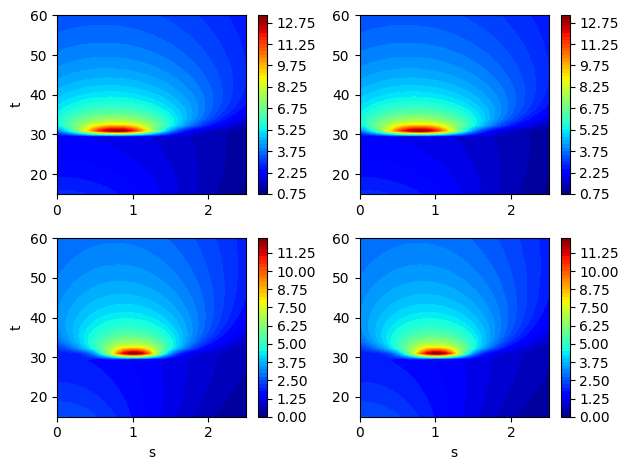

In [108]:
fig, ax = plt.subplots(2,2)

for i in range(2):
    for j in range(2):
        contour = ax[i,j].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), xtrain[i+3].numpy(force=True), levels = 50, cmap='jet')
        if i == 1:
            ax[i,j].set_xlabel("s") 
        if j == 0:
            ax[i,j].set_ylabel("t")
        fig.colorbar(contour, ax=ax[i,j])

plt.tight_layout()

## Constructing the POD model

Using `scimlstudio`, the `POD` class can be used to implement the method. This class has the following three required inputs:
- `s_train`: Snapshot or data matrix for the POD method. This must have dimensions $n \times m$, where $n$ is the number of outputs for the grid and $m$ is the number of samples in the matrix.
- `ric`: Relative information criterion for the model.
- `snapshot_transform`: Data transform for the snapshot or data matrix. Typically, the matrix is only centered to have zero mean. However, standardizing the snapshot matrix can lead to better results and therefore, standardization is used here. It is important to note that the matrix provided to the transform class must have dimensions $m \times n$. 

The following block of code builds the POD model using standardization as the transform and with an RIC value of 0.9999. After the model is created and fitted, the singular values and RIC are plotted to demonstrate how the POD model learns information from the data. 

Number of modes to meet RIC value: 15


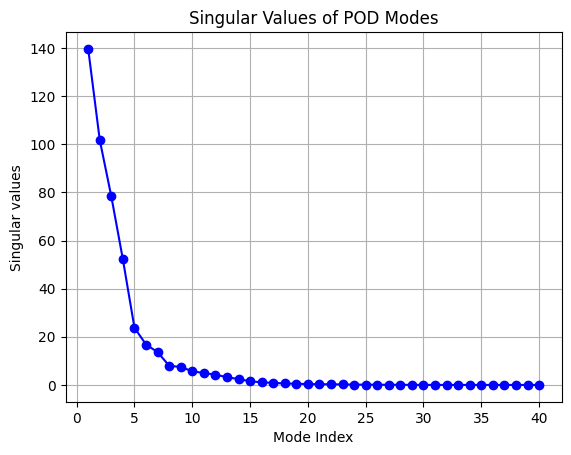

In [109]:
import numpy as np

# reshape the training data such that each column is the field and the number of columns 
# is the number of training samples
transform = Standardize(xtrain.flatten(1))
pod = POD(s_train=xtrain.flatten(1).mT, ric=0.9999, snapshot_transform=transform)
pod.fit()
print(f"Number of modes to meet RIC value: {pod.k}")

# plotting the singular values of the POD model
fig, ax = plt.subplots()
ax.plot(np.arange(1,xtrain.shape[0]+1), pod.S.numpy(force=True), 'bo-')
ax.set_ylabel('Singular values')
ax.set_xlabel('Mode Index')
ax.set_title('Singular Values of POD Modes')
ax.grid()

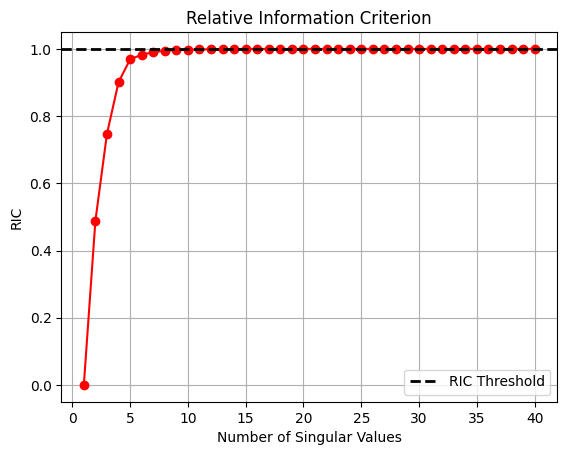

In [110]:
# plotting the ric values for the pod model
fig, ax = plt.subplots()
ax.plot(np.arange(1,xtrain.shape[0]+1), [ric.numpy(force=True) for ric in pod.ric_list], 'ro-')
ax.set_ylabel('RIC')
ax.set_xlabel('Number of Singular Values')
ax.set_title('Relative Information Criterion')
ax.axhline(pod.ric, color='k', linestyle='--', linewidth=2, label="RIC Threshold")
ax.legend(loc="best")
ax.grid()

From the plot of singular values and RIC shown above, most singular values are close to zero and only a few contribute to the information present in the snapshot matrix. Similarly, the plot of RIC demonstrates that only a few modes are required to meet the threshold of RIC specified. This fact is the reason that POD can project high-dimensional data to a low-dimensional representation. 

## Plotting the POD modes for the EMF

Now that the POD modes of the EMF have been generated, we can plot the modes to visualize. Each POD modes is also a field of the same dimension as the original data and it can be plotted on the same grid. Typically, the POD modes will reveal spatial or temporal structures within the data that you are analyzing. In this case, we can see the dominant spatial structures of the EMF within the POD modes.

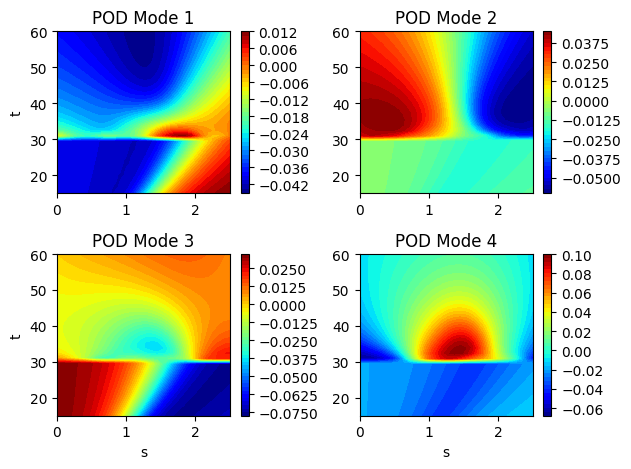

In [111]:
fig, ax = plt.subplots(2,2)
plotting_modes = [[pod.modes[:,0], pod.modes[:,1]], [pod.modes[:,2], pod.modes[:,3]]]
k = 0
for i in range(2):
    for j in range(2):
        contour = ax[i,j].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), plotting_modes[i][j].reshape(32,32).numpy(force=True), 
                                   levels = 50, cmap='jet')
        if i == 1:
            ax[i,j].set_xlabel("s") 
        if j == 0:
            ax[i,j].set_ylabel("t")
        ax[i,j].set_title(f"POD Mode {k+1}")
        fig.colorbar(contour, ax=ax[i,j])
        k+=1

plt.tight_layout()

## Reconstructing the EMF using the POD modes

Once the POD modes are generated, the data can also be projected to the low-dimensional space and then reconstructed. The projection can be done using the `encoding` method of the `POD` class and the reconstruction can be done from the low-dimensional coordinates using the `decoding` method of the `POD` class. This is demonstrated in the following code block:

In [112]:
# Projecting to low-dimensional coordinates
z = pod.encoding(xtrain.flatten(1).mT)
print("Shape of projection:", z.shape)
# Reconstructing
X = pod.decoding(z)
print("Shape of reconstruction:", X.shape)

Shape of projection: torch.Size([40, 15])
Shape of reconstruction: torch.Size([40, 1024])


The above computations show that the original 1024 outputs can actually be compressed to a representation with only 15 outputs and it is far easier to model 15 outputs than 1024 outputs. 

As noted at the start, if the process of projection and reconstruction are chained together, the POD model can act as a surrogate model that reconstructs its input. This can be done using the `predict` method in the `POD` class. This is demonstrated using the testing data generated earlier and the predictions are visualized. The absolute error between the predictions and the ground truth is also visualized to illustrate the distribution of error in the reconstruction of the POD model. It can be seen that the error is concentrated near $t=30$ where the discontinuity in the function occurs. POD is a linear dimensionality reduction method and therefore, cannot effectively capture a nonlinearity such as a discontinuity. However, the method is accurate in other regions of he grid that do not have a discontinuity. 

In [113]:
# using the predict method to reconstruct the EMF
predictions = pod.predict(xtest.flatten(1).mT)
predictions_reshaped = predictions.mT.reshape([100,32,32])

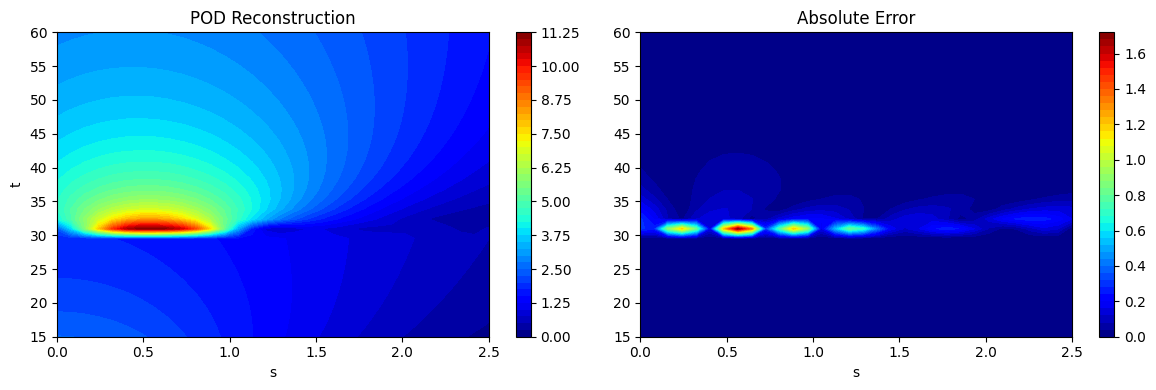

In [114]:
# plotting the reconstructions
fig, ax = plt.subplots(1,2, figsize=(12,4))

contour = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_reshaped[10].numpy(force=True), 
                         levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("POD Reconstruction")
fig.colorbar(contour, ax=ax[0])

contour = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(xtest[10] - predictions_reshaped[10]).numpy(force=True), 
                         levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Absolute Error")
fig.colorbar(contour, ax=ax[1])

plt.tight_layout()

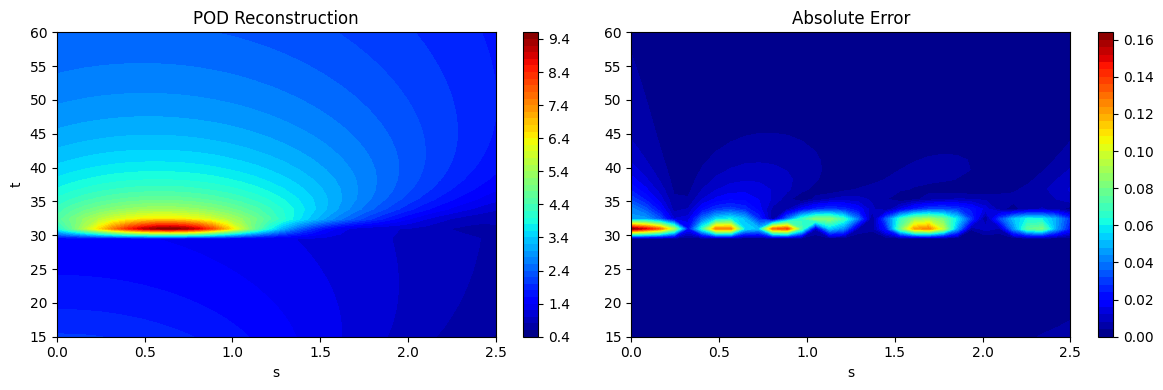

In [115]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

contour = ax[0].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), predictions_reshaped[20].numpy(force=True), levels = 50, cmap='jet')
ax[0].set_xlabel("s") 
ax[0].set_ylabel("t") 
ax[0].set_title("POD Reconstruction")
fig.colorbar(contour, ax=ax[0])

contour = ax[1].contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), abs(xtest[20] - predictions_reshaped[20]).numpy(force=True), levels = 50, cmap='jet')
ax[1].set_xlabel("s") 
ax[1].set_title("Absolute Error")
fig.colorbar(contour, ax=ax[1])

plt.tight_layout()

## Error metrics

While the absolute error plotted previously can elucidate the error in the reconstruction for a particular sample point, it is difficult to infer the overall reconstruction accuracy of the POD model using absolute error alone. This motivates the need for a different metric that can provide a sense of the overall accuracy of the POD model. 

In this case, we can calculate the normalized root mean squared error (NRMSE) for each grid point over which the field is evaluated. This NRMSE can be defined as

$$
\begin{gather*}
\text{NRMSE}^{st} = \frac{1}{\max(y^{st})-\min(y^{st})}\sqrt{\frac{1}{N}\sum_{j=1}^N(\hat{y}^{st}_j-y^{st}_j)^2}
\end{gather*}
$$

where $st$ indicates the NRMSE is being calculated at $(s,t)$. $\hat{y}^{st}$ represents the prediction of the model at $(s,t)$ and $y^{st}$ represents the ground truth value at $(s,t)$. Once the NRMSE is calculated at each grid point, it can be plotted as a contour plot to visualize the error of the reconstruction across all testing points over the grid. We can also use the mean NRMSE over the whole grid as a single aggregated value that represents the error in the reconstruction of the POD model. However, it is always best to plot the contours of the NRMSE as the aggregated value can be misleading when assessing the accuracy of the reconstruction. 

The next block of code calculates the NRMSE using the `evaluate_vector` function from `scimlstudio` and plots the NRMSE contours. It also shows that the error is accumulated near the location of the discontinuity in the function. Values of the function far from the discontinuity are well reconstructed by the POD method.

Average value of NRMSE across grid: 0.00790669396519661


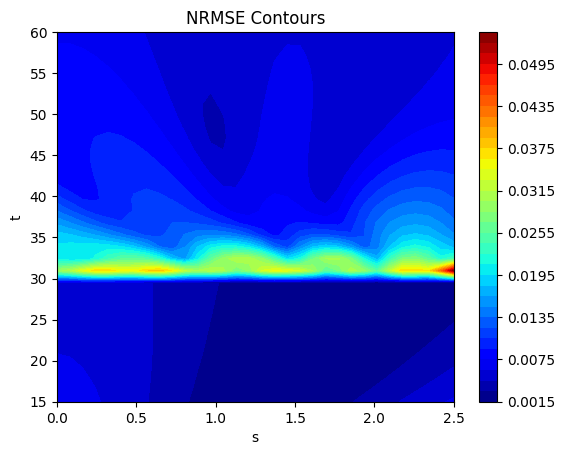

In [116]:
# calculating the nrmse for each grid point
nrmse = evaluate_vector(true_values=xtest.flatten(1), predict_values=predictions.mT, metric="nrmse")
print(f"Average value of NRMSE across grid: {torch.mean(nrmse)}")

# plotting the nrmse
fig, ax = plt.subplots()
contour = ax.contourf(Sgrid.numpy(force=True), Tgrid.numpy(force=True), nrmse.reshape(32,32).numpy(force=True), levels = 50, cmap='jet')
ax.set_xlabel("s") 
ax.set_ylabel("t") 
ax.set_title("NRMSE Contours")
fig.colorbar(contour, ax=ax)